In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
df = pd.read_csv(r"D:\projects\codveda project\csv\3) Sentiment dataset.csv")

In [3]:
df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,1/15/2023 12:30,User123,Twitter,#Nature #Park,15,30,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,1/15/2023 8:45,CommuterX,Twitter,#Traffic #Morning,5,10,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,1/15/2023 15:45,FitnessFan,Instagram,#Fitness #Workout,20,40,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,1/15/2023 18:20,AdventureX,Facebook,#Travel #Adventure,8,15,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,1/15/2023 19:55,ChefCook,Instagram,#Cooking #Food,12,25,Australia,2023,1,15,19


In [4]:
df.shape

(732, 15)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0.1  732 non-null    int64 
 1   Unnamed: 0    732 non-null    int64 
 2   Text          732 non-null    object
 3   Sentiment     732 non-null    object
 4   Timestamp     732 non-null    object
 5   User          732 non-null    object
 6   Platform      732 non-null    object
 7   Hashtags      732 non-null    object
 8   Retweets      732 non-null    int64 
 9   Likes         732 non-null    int64 
 10  Country       732 non-null    object
 11  Year          732 non-null    int64 
 12  Month         732 non-null    int64 
 13  Day           732 non-null    int64 
 14  Hour          732 non-null    int64 
dtypes: int64(8), object(7)
memory usage: 85.9+ KB


In [6]:
df.drop("Unnamed: 0", axis=1, inplace=True)

In [7]:
df["Text"] = df["Text"].str.strip()
df["Sentiment"] = df["Sentiment"].str.strip()
df["User"] = df["User"].str.strip()
df["Platform"] = df["Platform"].str.strip()
df["Hashtags"] = df["Hashtags"].str.strip()
df["Country"] = df["Country"].str.strip()

In [8]:
df["Platform"].unique()
df["Country"].unique()

array(['USA', 'Canada', 'UK', 'Australia', 'India', 'France', 'Brazil',
       'Japan', 'Greece', 'Germany', 'Sweden', 'Italy', 'Netherlands',
       'South Africa', 'Spain', 'Portugal', 'Switzerland', 'Austria',
       'Belgium', 'Denmark', 'Czech Republic', 'Jordan', 'Peru',
       'Maldives', 'China', 'Cambodia', 'Norway', 'Colombia', 'Ireland',
       'Jamaica', 'Kenya', 'Scotland', 'Thailand'], dtype=object)

In [9]:
df["Sentiment"].unique()


array(['Positive', 'Negative', 'Neutral', 'Anger', 'Fear', 'Sadness',
       'Disgust', 'Happiness', 'Joy', 'Love', 'Amusement', 'Enjoyment',
       'Admiration', 'Affection', 'Awe', 'Disappointed', 'Surprise',
       'Acceptance', 'Adoration', 'Anticipation', 'Bitter', 'Calmness',
       'Confusion', 'Excitement', 'Kind', 'Pride', 'Shame', 'Elation',
       'Euphoria', 'Contentment', 'Serenity', 'Gratitude', 'Hope',
       'Empowerment', 'Compassion', 'Tenderness', 'Arousal', 'Enthusiasm',
       'Fulfillment', 'Reverence', 'Despair', 'Grief', 'Loneliness',
       'Jealousy', 'Resentment', 'Frustration', 'Boredom', 'Anxiety',
       'Intimidation', 'Helplessness', 'Envy', 'Regret', 'Curiosity',
       'Indifference', 'Numbness', 'Melancholy', 'Nostalgia',
       'Ambivalence', 'Determination', 'Zest', 'Hopeful', 'Proud',
       'Grateful', 'Empathetic', 'Compassionate', 'Playful',
       'Free-spirited', 'Inspired', 'Confident', 'Bitterness', 'Yearning',
       'Fearful', 'Apprehensiv

In [10]:
df.isnull().sum()

Unnamed: 0.1    0
Text            0
Sentiment       0
Timestamp       0
User            0
Platform        0
Hashtags        0
Retweets        0
Likes           0
Country         0
Year            0
Month           0
Day             0
Hour            0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

In [13]:
df.dtypes

Unnamed: 0.1             int64
Text                    object
Sentiment               object
Timestamp       datetime64[ns]
User                    object
Platform                object
Hashtags                object
Retweets                 int64
Likes                    int64
Country                 object
Year                     int64
Month                    int64
Day                      int64
Hour                     int64
dtype: object

In [14]:
df["Retweets"] = df["Retweets"].astype(int)

In [15]:
df["Likes"] = df["Likes"].astype(int)

In [16]:
df["Year"] = df["Year"].astype(int)
df["Month"] = df["Month"].astype(int)
df["Day"] = df["Day"].astype(int)
df["Hour"] = df["Hour"].astype(int)

In [17]:
df["Platform"] = df["Platform"].astype("category")
df["Sentiment"] = df["Sentiment"].astype("category")
df["Country"] = df["Country"].astype("category")

In [18]:
df.head()

,Unnamed: 0.1,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,Enjoying a beautiful day at the park!,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15,30,USA,2023,1,15,12
1,1,Traffic was terrible this morning.,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5,10,Canada,2023,1,15,8
2,2,Just finished an amazing workout! 💪,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20,40,USA,2023,1,15,15
3,3,Excited about the upcoming weekend getaway!,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8,15,UK,2023,1,15,18
4,4,Trying out a new recipe for dinner tonight.,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12,25,Australia,2023,1,15,19


In [19]:
df["Sentiment"].value_counts()


Sentiment
Positive                45
Joy                     44
Excitement              37
Contentment             19
Gratitude               18
Neutral                 18
Curiosity               16
Serenity                15
Happy                   14
Nostalgia               11
Despair                 11
Awe                      9
Grief                    9
Loneliness               9
Hopeful                  9
Sad                      9
Confusion                8
Acceptance               8
Embarrassed              8
Elation                  7
Pride                    7
Euphoria                 7
Enthusiasm               7
Determination            7
Hate                     6
Bad                      6
Ambivalence              6
Inspiration              6
Melancholy               6
Regret                   6
Playful                  6
Numbness                 6
Surprise                 6
Indifference             6
Frustration              6
Empowerment              5
Inspired          

In [20]:
sentiment_map = {
    # Positive
    "Positive": "Positive",
    "Happiness": "Positive",
    "Joy": "Positive",
    "Love": "Positive",
    "Admiration": "Positive",
    "Gratitude": "Positive",
    "Hope": "Positive",
    "Excitement": "Positive",
    "Amusement": "Positive",
    "Enjoyment": "Positive",
    "Affection": "Positive",
    "Awe": "Positive",
    "Surprise": "Positive",
    "Acceptance": "Positive",
    "Adoration": "Positive",
    "Anticipation": "Positive",
    "Calmness": "Positive",
    "Enthusiasm": "Positive",
    "Pride": "Positive",
    "Elation": "Positive",
    "Euphoria": "Positive",
    "Contentment": "Positive",
    "Serenity": "Positive",
    "Empowerment": "Positive",
    "Compassion": "Positive",
    "Tenderness": "Positive",
    "Reverence": "Positive",
    "Fulfillment": "Positive",
    "Arousal": "Positive",
    "Kind": "Positive",

    # Negative
    "Negative": "Negative",
    "Anger": "Negative",
    "Fear": "Negative",
    "Sadness": "Negative",
    "Disgust": "Negative",
    "Disappointed": "Negative",
    "Bitter": "Negative",
    "Shame": "Negative",
    "Confusion": "Negative",
    "Despair": "Negative",
    "Grief": "Negative",
    "Loneliness": "Negative",
    "Jealousy": "Negative",
    "Resentment": "Negative",
    "Frustration": "Negative",
    "Boredom": "Negative",
    "Anxiety": "Negative",
    "Intimidation": "Negative",
    "Helplessness": "Negative",
    "Envy": "Negative",
    "Regret": "Negative",

    # Neutral
    "Neutral": "Neutral"
}


In [21]:
df["Sentiment_Category"] =  df["Sentiment"].map(sentiment_map)

In [22]:
df["Sentiment_Category"].value_counts()

Sentiment_Category
Positive    290
Negative     90
Neutral      18
Name: count, dtype: int64

In [23]:
df["Sentiment_Category"].isnull().sum()

np.int64(334)

In [24]:
df[df["Sentiment_Category"].isnull()]["Sentiment"].unique()

['Curiosity', 'Indifference', 'Numbness', 'Melancholy', 'Nostalgia', ..., 'Mischievous', 'Sad', 'Hate', 'Bad', 'Happy']
Length: 139
Categories (191, object): ['Acceptance', 'Accomplishment', 'Admiration', 'Adoration', ..., 'Wonder', 'Wonderment', 'Yearning', 'Zest']

In [25]:
df["Sentiment_Category"] = df["Sentiment_Category"].fillna("Neutral")

In [26]:
df["Sentiment_Category"].isnull().sum()

np.int64(0)

In [27]:
df["Engagement"] = df["Retweets"] + df["Likes"]

In [28]:
def time_of_day(hour):
    if 6<= hour <12:
        return "morning"
    elif 12<= hour <18:
        return "afternoon"
    elif 18<= hour < 24:
        return "evening"
    else:
        return "night"

df["Time_Period"] = df["Hour"].apply(time_of_day)

C:\Users\asust\AppData\Local\Temp\ipykernel_25052\153172124.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Platform", palette="Set2")


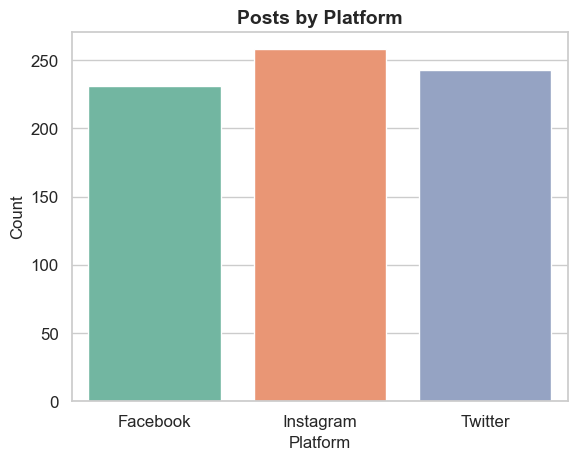

In [42]:
import seaborn as sns
sns.set_theme(style="whitegrid", font_scale=1.1)


sns.countplot(data=df, x="Platform", palette="Set2")
plt.title("Posts by Platform", fontsize=14, fontweight="bold")
plt.xlabel("Platform", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.savefig(r"D:\projects\codveda project\plots\Posts by Platform.png", 
            dpi=300, bbox_inches="tight")
plt.show()


C:\Users\asust\AppData\Local\Temp\ipykernel_25052\1233038123.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="Sentiment_Category", palette="Set2",


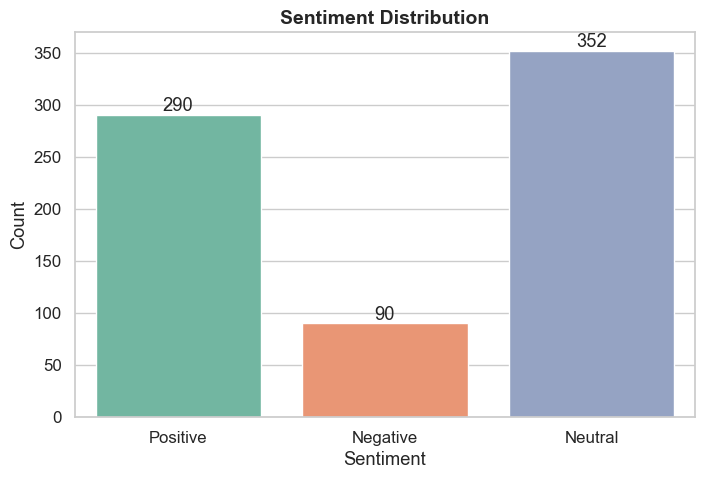

In [41]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x="Sentiment_Category", palette="Set2", 
                   order=["Positive", "Negative", "Neutral"])
plt.title("Sentiment Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Sentiment")
plt.ylabel("Count")

for container in ax.containers:
    ax.bar_label(container)
plt.savefig(r"D:\projects\codveda project\plots\Sentiment Distribution.png", 
            dpi=300, bbox_inches="tight")
plt.show()

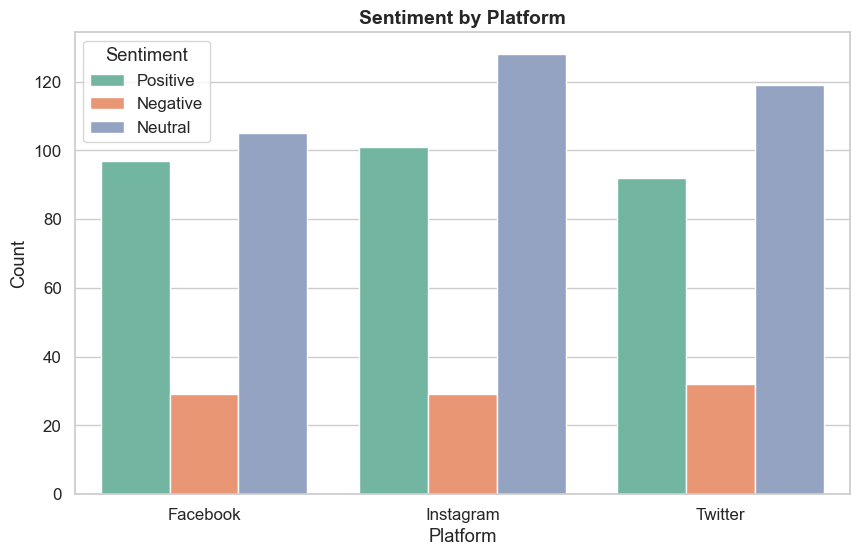

In [40]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="Platform", hue="Sentiment_Category", palette="Set2")
plt.title("Sentiment by Platform", fontsize=14, fontweight="bold")
plt.xlabel("Platform")
plt.ylabel("Count")
plt.legend(title="Sentiment")
plt.savefig(r"D:\projects\codveda project\plots\sentiment_by_platform.png", 
            dpi=300, bbox_inches="tight")
plt.show()

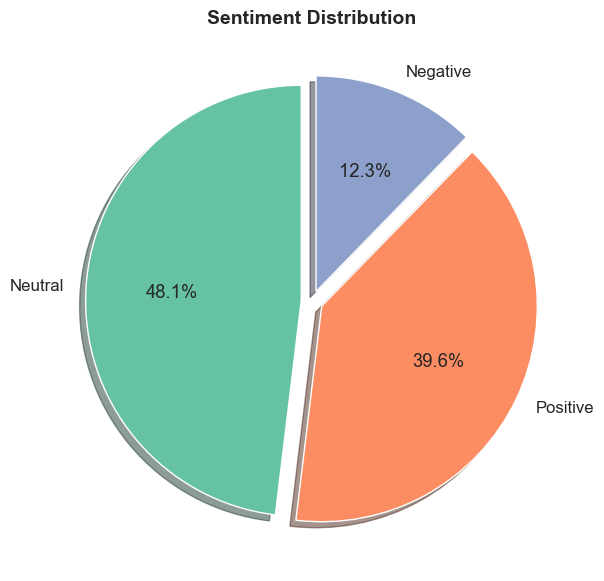

In [43]:
plt.figure(figsize=(7, 7))
df["Sentiment_Category"].value_counts().plot(
    kind="pie", 
    autopct="%1.1f%%", 
    colors=["#66c2a5", "#fc8d62", "#8da0cb"],
    startangle=90,
    explode=[0.05, 0.05, 0.05],
    shadow=True
)
plt.title("Sentiment Distribution", fontsize=14, fontweight="bold")
plt.ylabel("")
plt.savefig(r"D:\projects\codveda project\plots\Sentiment_Category.png", 
            dpi=300, bbox_inches="tight")
plt.show()

In [44]:
df.head()

,Unnamed: 0.1,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour,Sentiment_Category,Engagement,Time_Period
0,0,Enjoying a beautiful day at the park!,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15,30,USA,2023,1,15,12,Positive,45,afternoon
1,1,Traffic was terrible this morning.,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5,10,Canada,2023,1,15,8,Negative,15,morning
2,2,Just finished an amazing workout! 💪,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20,40,USA,2023,1,15,15,Positive,60,afternoon
3,3,Excited about the upcoming weekend getaway!,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8,15,UK,2023,1,15,18,Positive,23,evening
4,4,Trying out a new recipe for dinner tonight.,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12,25,Australia,2023,1,15,19,Neutral,37,evening


In [45]:
df.to_csv(r"D:\projects\codveda project\task 1\cleaned csv\cleaned_sentiment_data.csv", index=False)
